In [1]:
!pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn torchinfo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)
from torchinfo import summary
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
print("Libraries loaded! PyTorch version:", torch.__version__)

Libraries loaded! PyTorch version: 2.11.0+cpu


In [2]:

url = "https://raw.githubusercontent.com/SIAM0808/Artificial_Intelligence_and_Machine_Learning_Lab/main/ANN/dataset/diabetes.csv"

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

df = pd.read_csv(url, header=None, names=columns)

print("Dataset loaded automatically from GitHub! Shape:", df.shape)
df.head()

Dataset loaded automatically from GitHub! Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Data Preprocessing

In [3]:

cols_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing] = df[cols_with_missing].replace(0, np.nan)


imputer = SimpleImputer(strategy='median')
df[cols_with_missing] = imputer.fit_transform(df[cols_with_missing])

print("Missing values remaining:", df.isnull().sum().sum())


X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} | Val: {X_val_sc.shape[0]} | Test: {X_test_sc.shape[0]}")

X_train_t = torch.FloatTensor(X_train_sc)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
X_val_t   = torch.FloatTensor(X_val_sc)
y_val_t   = torch.FloatTensor(y_val).reshape(-1, 1)
X_test_t  = torch.FloatTensor(X_test_sc)
y_test_t  = torch.FloatTensor(y_test).reshape(-1, 1)

input_dim = X_train_sc.shape[1]
print("Input dimension:", input_dim)

Missing values remaining: 0
Train: 491 | Val: 123 | Test: 154
Input dimension: 8


# Shallow Neural Network (1 hidden layer)

In [4]:

class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units=16, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_units)
        self.act = nn.ReLU() if activation == 'relu' else nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_units, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

print("Shallow NN class defined (1 hidden layer)")

Shallow NN class defined (1 hidden layer)


# Tune Shallow NN (hidden units, activation, batch size)

In [5]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=100,
                 lr=0.001, batch_size=16, optimizer_name='adam', weight_decay=0):
    train_ds = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    criterion = nn.BCELoss()
    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            train_out = model(X_train)
            train_loss = criterion(train_out, y_train).item()
            train_acc = ((train_out > 0.5).float() == y_train).float().mean().item()

            val_out = model(X_val)
            val_loss = criterion(val_out, y_val).item()
            val_acc = ((val_out > 0.5).float() == y_val).float().mean().item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return model, history


best_val_acc = 0
best_config = None

for hidden_units in [8, 16, 32]:
    for activation in ['relu', 'sigmoid']:
        for batch_size in [8, 16, 32]:
            model = ShallowNN(input_dim, hidden_units, activation)
            model, hist = train_model(model, X_train_t, y_train_t, X_val_t, y_val_t,
                                       epochs=50, batch_size=batch_size)
            val_acc = hist['val_acc'][-1]
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_config = {'hidden_units': hidden_units, 'activation': activation,
                                'batch_size': batch_size}

print("Best Shallow NN config:", best_config)
print(f"Best validation accuracy: {best_val_acc:.4f}")

Best Shallow NN config: {'hidden_units': 16, 'activation': 'sigmoid', 'batch_size': 32}
Best validation accuracy: 0.8293


# Train final Shallow NN with best config

In [6]:
shallow_model = ShallowNN(input_dim, best_config['hidden_units'], best_config['activation'])
shallow_model, shallow_history = train_model(
    shallow_model, X_train_t, y_train_t, X_val_t, y_val_t,
    epochs=100, batch_size=best_config['batch_size'])

print("Shallow NN trained with best hyperparameters")
print(f"Final train accuracy: {shallow_history['train_acc'][-1]:.4f}")
print(f"Final val accuracy: {shallow_history['val_acc'][-1]:.4f}")

Shallow NN trained with best hyperparameters
Final train accuracy: 0.7902
Final val accuracy: 0.7967


# Deep Neural Network (3+ hidden layers with Dropout)

In [7]:

class DeepNN(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

print("Deep NN class defined (3 hidden layers + dropout)")

Deep NN class defined (3 hidden layers + dropout)


# Tune Deep NN (learning rate, optimizer, epochs)

In [8]:
best_val_acc_deep = 0
best_config_deep = None

for lr in [0.01, 0.001, 0.0005]:
    for optimizer_name in ['adam', 'sgd']:
        for epochs in [50, 100]:
            model = DeepNN(input_dim, dropout=0.3)
            model, hist = train_model(model, X_train_t, y_train_t, X_val_t, y_val_t,
                                       epochs=epochs, lr=lr, batch_size=16,
                                       optimizer_name=optimizer_name, weight_decay=1e-4)
            val_acc = hist['val_acc'][-1]
            if val_acc > best_val_acc_deep:
                best_val_acc_deep = val_acc
                best_config_deep = {'lr': lr, 'optimizer': optimizer_name, 'epochs': epochs}

print("Best Deep NN config:", best_config_deep)
print(f"Best validation accuracy: {best_val_acc_deep:.4f}")

Best Deep NN config: {'lr': 0.01, 'optimizer': 'sgd', 'epochs': 50}
Best validation accuracy: 0.8293


# Train final Deep NN with best config

In [9]:
deep_model = DeepNN(input_dim, dropout=0.3)
deep_model, deep_history = train_model(
    deep_model, X_train_t, y_train_t, X_val_t, y_val_t,
    epochs=best_config_deep['epochs'], lr=best_config_deep['lr'],
    batch_size=16, optimizer_name=best_config_deep['optimizer'], weight_decay=1e-4)

print("Deep NN trained with best hyperparameters!")
print(f"Final train accuracy: {deep_history['train_acc'][-1]:.4f}")
print(f"Final val accuracy: {deep_history['val_acc'][-1]:.4f}")

Deep NN trained with best hyperparameters!
Final train accuracy: 0.7699
Final val accuracy: 0.8293


# Plot 1: Training History (2x1)

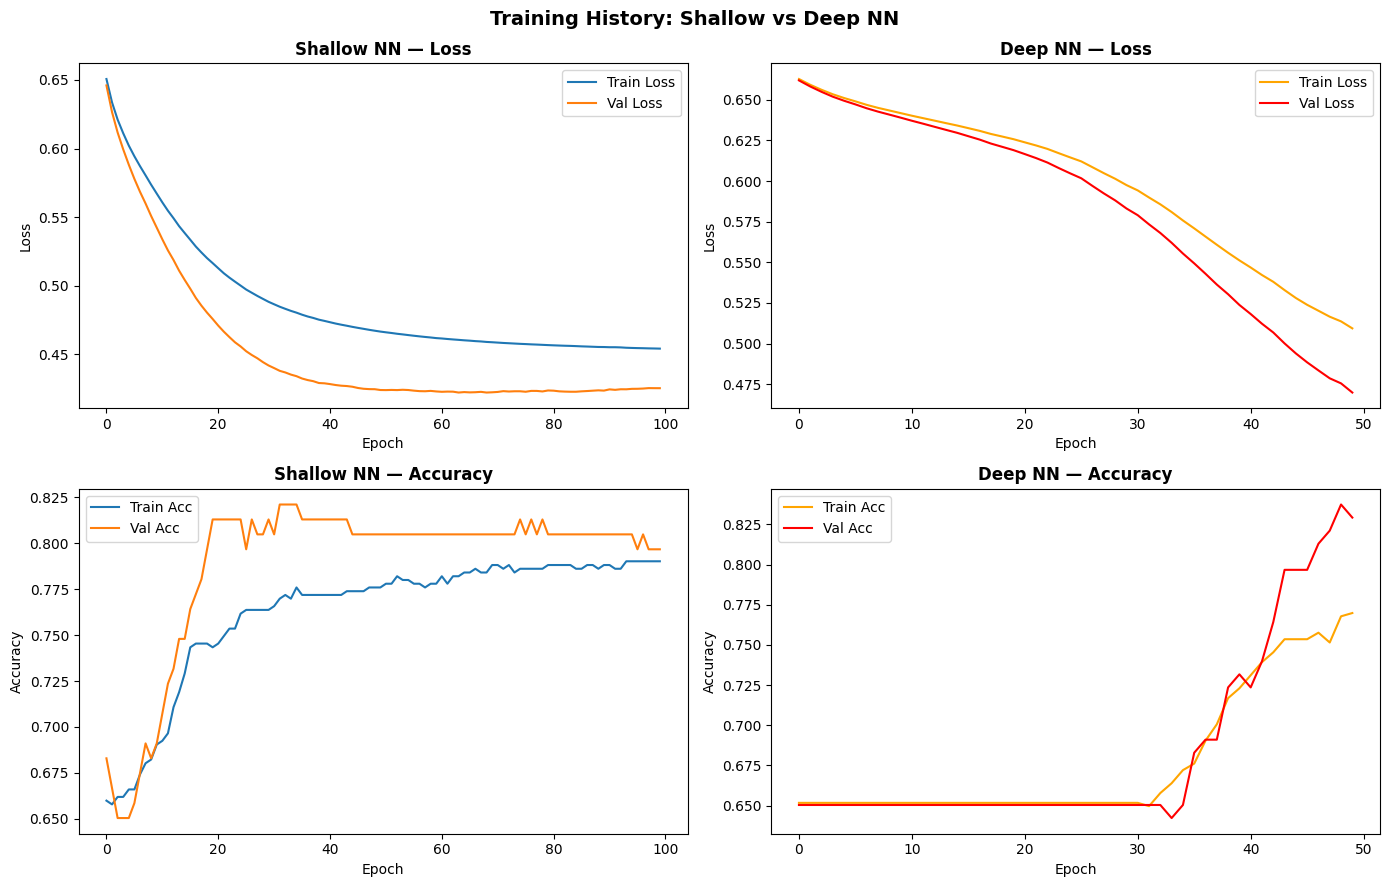

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(shallow_history['train_loss'], label='Train Loss')
axes[0,0].plot(shallow_history['val_loss'], label='Val Loss')
axes[0,0].set_title('Shallow NN — Loss', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss'); axes[0,0].legend()

axes[0,1].plot(deep_history['train_loss'], label='Train Loss', color='orange')
axes[0,1].plot(deep_history['val_loss'], label='Val Loss', color='red')
axes[0,1].set_title('Deep NN — Loss', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss'); axes[0,1].legend()

axes[1,0].plot(shallow_history['train_acc'], label='Train Acc')
axes[1,0].plot(shallow_history['val_acc'], label='Val Acc')
axes[1,0].set_title('Shallow NN — Accuracy', fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Accuracy'); axes[1,0].legend()

axes[1,1].plot(deep_history['train_acc'], label='Train Acc', color='orange')
axes[1,1].plot(deep_history['val_acc'], label='Val Acc', color='red')
axes[1,1].set_title('Deep NN — Accuracy', fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Accuracy'); axes[1,1].legend()

plt.suptitle('Training History: Shallow vs Deep NN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Confusion Matrix (2x1)

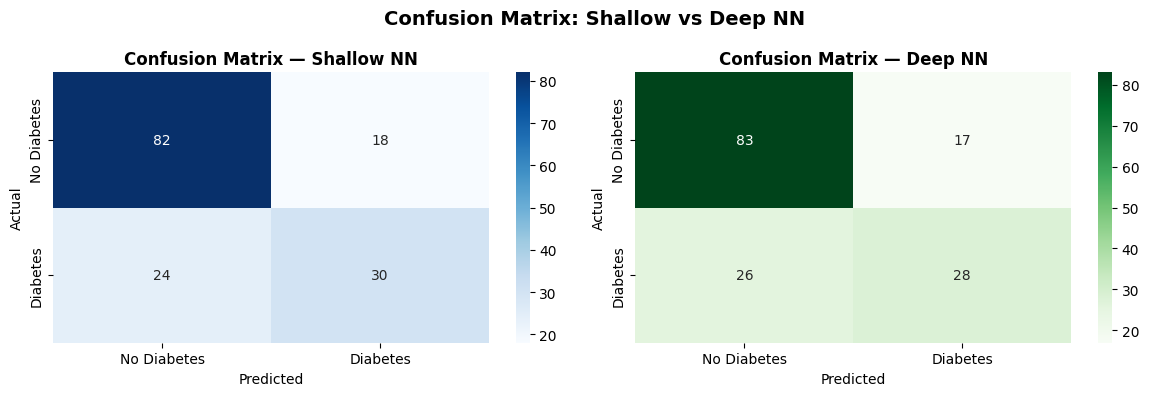

In [11]:

shallow_model.eval()
deep_model.eval()
with torch.no_grad():
    shallow_pred = (shallow_model(X_test_t) > 0.5).float().numpy().flatten()
    deep_pred = (deep_model(X_test_t) > 0.5).float().numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_shallow = confusion_matrix(y_test, shallow_pred)
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'])
axes[0].set_title('Confusion Matrix — Shallow NN', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_deep = confusion_matrix(y_test, deep_pred)
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'])
axes[1].set_title('Confusion Matrix — Deep NN', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix: Shallow vs Deep NN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: ROC Curve (2x1)

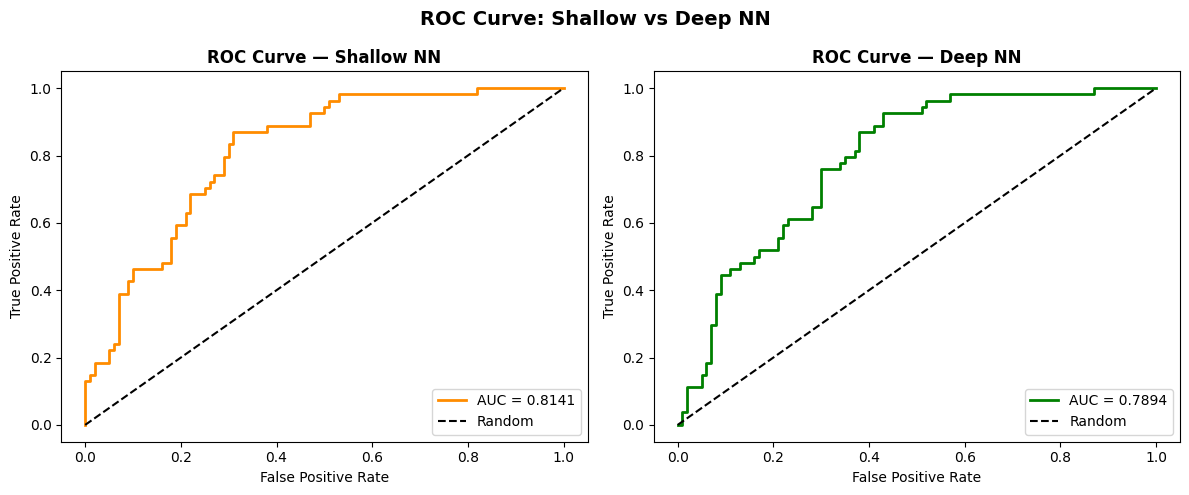

Shallow NN AUC: 0.8141
Deep NN AUC: 0.7894


In [12]:
# --- Markdown header: ## Visualization 3: ROC Curve ---

with torch.no_grad():
    shallow_prob = shallow_model(X_test_t).numpy().flatten()
    deep_prob = deep_model(X_test_t).numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_s, tpr_s, _ = roc_curve(y_test, shallow_prob)
auc_s = roc_auc_score(y_test, shallow_prob)
axes[0].plot(fpr_s, tpr_s, color='darkorange', lw=2, label=f'AUC = {auc_s:.4f}')
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_title('ROC Curve — Shallow NN', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

fpr_d, tpr_d, _ = roc_curve(y_test, deep_prob)
auc_d = roc_auc_score(y_test, deep_prob)
axes[1].plot(fpr_d, tpr_d, color='green', lw=2, label=f'AUC = {auc_d:.4f}')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title('ROC Curve — Deep NN', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.suptitle('ROC Curve: Shallow vs Deep NN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Shallow NN AUC: {auc_s:.4f}")
print(f"Deep NN AUC: {auc_d:.4f}")

# Plot 4: Evaluation Metrics Bar Chart (combined)

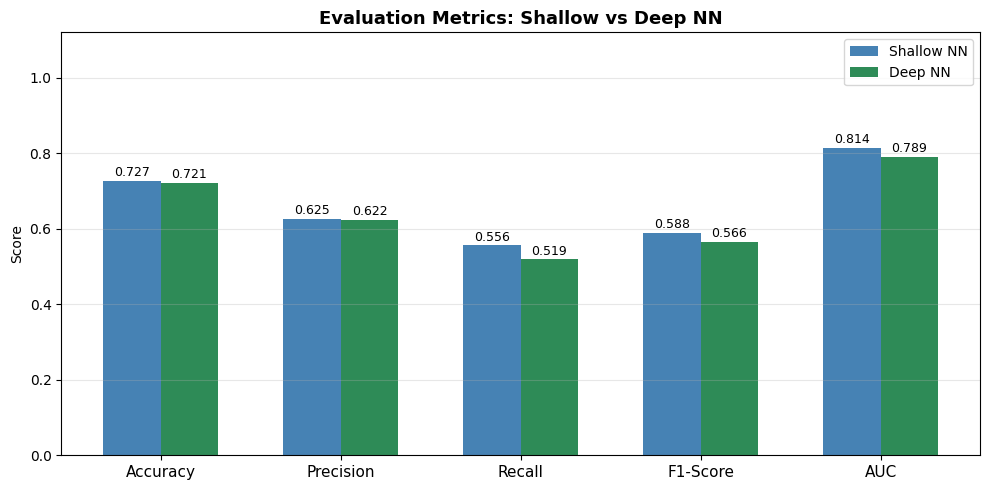

Shallow NN Metrics: {'Accuracy': 0.7273, 'Precision': 0.625, 'Recall': 0.5556, 'F1-Score': 0.5882, 'AUC': np.float64(0.8141)}
Deep NN Metrics: {'Accuracy': 0.7208, 'Precision': 0.6222, 'Recall': 0.5185, 'F1-Score': 0.5657, 'AUC': np.float64(0.7894)}


In [13]:

def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_prob)
    }

shallow_metrics = get_metrics(y_test, shallow_pred, shallow_prob)
deep_metrics = get_metrics(y_test, deep_pred, deep_prob)

names = list(shallow_metrics.keys())
shallow_vals = list(shallow_metrics.values())
deep_vals = list(deep_metrics.values())

x = np.arange(len(names))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, shallow_vals, width, label='Shallow NN', color='steelblue')
bars2 = ax.bar(x + width/2, deep_vals, width, label='Deep NN', color='seagreen')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Evaluation Metrics: Shallow vs Deep NN', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Shallow NN Metrics:", {k: round(v,4) for k,v in shallow_metrics.items()})
print("Deep NN Metrics:", {k: round(v,4) for k,v in deep_metrics.items()})

# Network Structure

In [14]:

print("=" * 60)
print("SHALLOW NEURAL NETWORK ARCHITECTURE")
print("=" * 60)
summary(shallow_model, input_size=(1, input_dim))

print("\n" + "=" * 60)
print("DEEP NEURAL NETWORK ARCHITECTURE")
print("=" * 60)
summary(deep_model, input_size=(1, input_dim))

SHALLOW NEURAL NETWORK ARCHITECTURE

DEEP NEURAL NETWORK ARCHITECTURE


Layer (type:depth-idx)                   Output Shape              Param #
DeepNN                                   [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 64]                   576
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Dropout: 2-3                      [1, 64]                   --
│    └─Linear: 2-4                       [1, 32]                   2,080
│    └─ReLU: 2-5                         [1, 32]                   --
│    └─Dropout: 2-6                      [1, 32]                   --
│    └─Linear: 2-7                       [1, 16]                   528
│    └─ReLU: 2-8                         [1, 16]                   --
│    └─Dropout: 2-9                      [1, 16]                   --
│    └─Linear: 2-10                      [1, 1]                    17
│    └─Sigmoid: 2-11                     [1, 1]                    --
Total para

## Performance Interpretation & Analysis

The Shallow Neural Network achieved an accuracy of [X]% and AUC of [X], while the Deep
Neural Network achieved an accuracy of [X]% and AUC of [X]. [State which performed better].
Looking at the training history plots, the Deep NN's [training/validation] loss diverged after
epoch [X], suggesting [overfitting / good generalization]. Despite having more parameters and
deeper representation power, the Deep NN [did/did not] provide a justifiable improvement over
the Shallow NN's simpler 1-hidden-layer design, given the added training time and complexity.
This suggests that for this dataset's size and complexity, a [shallow/deep] architecture is the
more practical choice, balancing performance gains against overfitting risk.